# Customer Churn Analysis

### Objective
##### This project aims to analyze customer churn behavior and identify the key factors that influence customer retention.

### Import Libraries

##### Import the required Python libraries for data manipulation and visualization.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette(["#488f31", "#7ca869", "#abc1a1"])

In [35]:
df = pd.read_csv('Customer_Deatil.csv')

In [36]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data Cleaning & Preprocessing

##### Prepare the dataset by handling missing values, correcting data types, and transforming variables for analysis.

In [39]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [41]:
df.isnull().sum().sum()

np.int64(0)

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df["SeniorCitizen"] = df["SeniorCitizen"].replace({0:"No", 1:"Yes"})
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


### Churn Distribution

##### This bar chart shows the number of customers who stayed with the company and those who churned. It helps compare the distribution of churned and retained customers to understand the overall churn rate.

<function matplotlib.pyplot.show(close=None, block=None)>

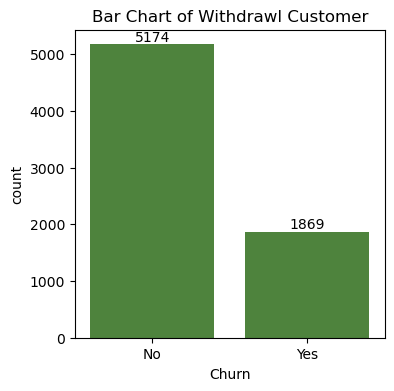

In [44]:
plt.figure(figsize=(4,4))
withdraw = sns.countplot(x = "Churn", data = df)
withdraw.bar_label(withdraw.containers[0])
plt.title("Bar Chart of Withdrawl Customer")
plt.show

### Customer Churn Percentage

##### This pie chart illustrates the percentage of customers who churned and those who remained. It provides a clear view of the overall customer churn distribution.

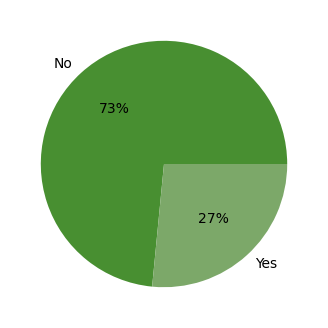

In [45]:
plt.figure(figsize=(4,4))
withdraw_in_pie = df.groupby("Churn").agg({"Churn": "count"})
plt.pie(withdraw_in_pie["Churn"],labels =withdraw_in_pie.index, autopct = "%1.0f%%")
plt.show()

### Gender-wise Customer Churn

##### This bar chart compares the number of male and female customers based on their churn status. It helps identify whether customer churn differs across genders.

<function matplotlib.pyplot.show(close=None, block=None)>

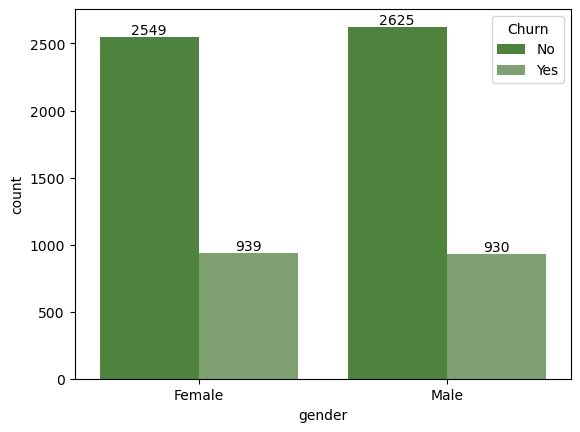

In [46]:
x= sns.countplot(x = "gender", data=df, hue= "Churn")
x.bar_label(x.containers[0])
x.bar_label(x.containers[1])
plt.show

### Customer Tenure Distribution

##### This histogram shows the distribution of customer tenure based on churn status. It helps identify whether customers with shorter or longer tenure are more likely to churn.

<function matplotlib.pyplot.show(close=None, block=None)>

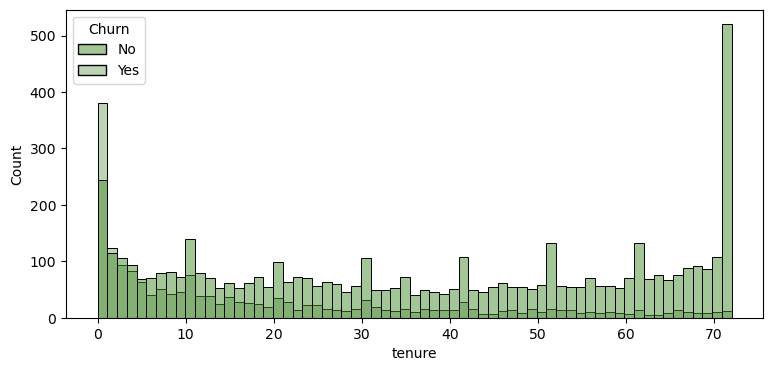

In [47]:
plt.figure(figsize=(9,4))
sns.histplot(x = "tenure", data = df, hue = "Churn", bins = 65)
plt.show


### Contract Type vs Customer Churn

##### This bar chart compares customer churn across different contract types. It helps identify which contract type has the highest likelihood of customer churn.

<function matplotlib.pyplot.show(close=None, block=None)>

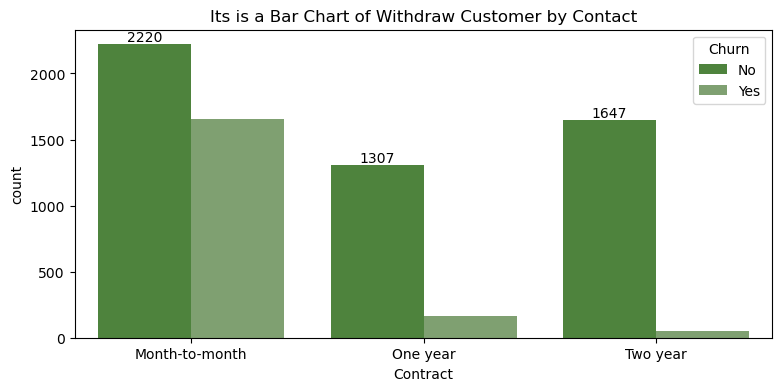

In [48]:
plt.figure(figsize=(9,4))
withdraw = sns.countplot(x = "Contract", data = df, hue = "Churn")
withdraw.bar_label(withdraw.containers[0])
plt.title("Its is a Bar Chart of Withdraw Customer by Contact")
plt.show

In [49]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

### Distribution of Telecom Services

##### These count plots display the distribution of customers across different telecom services and service options, including phone service, internet service, online security, streaming services, and technical support. They provide an overview of customer subscription patterns for each service.

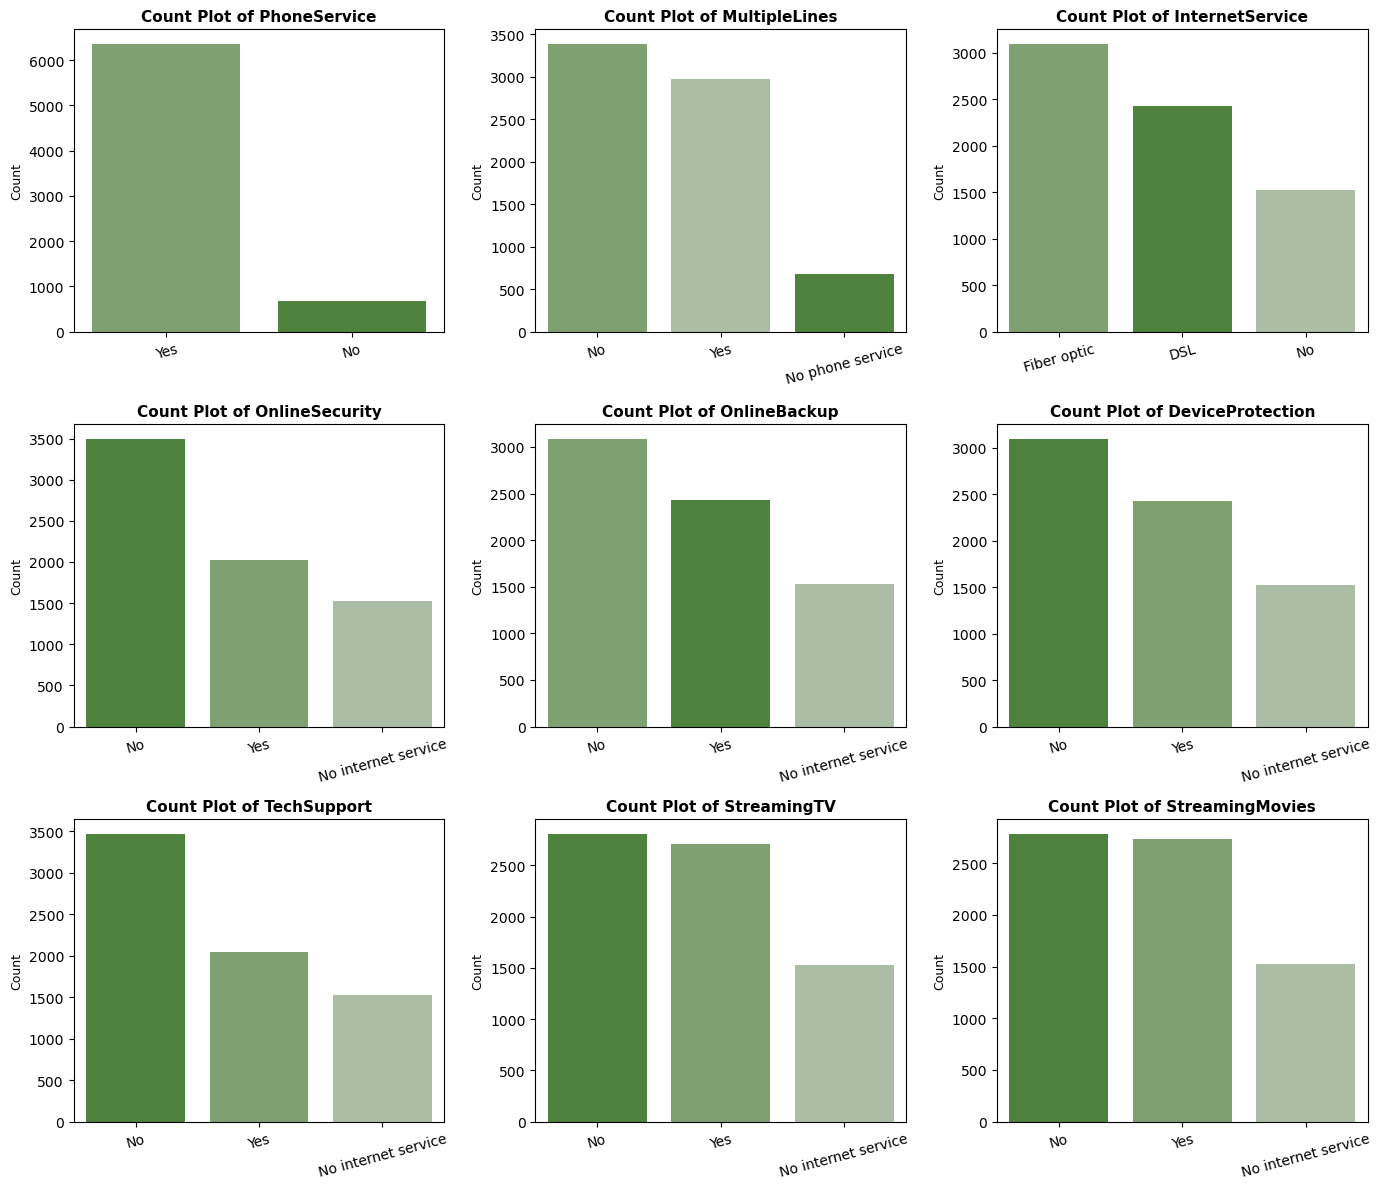

In [50]:
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies']


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(columns):
    order = df[col].value_counts().index

    
    sns.countplot(
        data=df, x=col, ax=axes[i], order=order, hue=col, legend=False
    )

    axes[i].set_title(f"Count Plot of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count", fontsize=9)
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("subplots_countplots.png", dpi=300)

plt.show()

### Monthly Charges by Customer Churn

##### This box plot compares the distribution of monthly charges for churned and retained customers. It helps identify whether customers with higher monthly charges are more likely to churn.

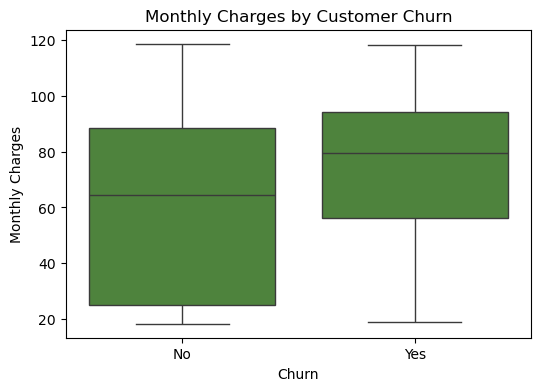

In [51]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()